# Thực hành CLIP — Câu 5

## 1. Cài đặt thư viện

`https://github.com/openai/CLIP`


In [1]:
!pip -q install ftfy regex tqdm
!pip -q install git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


## 2. Import và kiểm tra môi trường

In [2]:
import os
import random
import numpy as np
import torch
import clip

from PIL import Image
from torchvision.datasets import CIFAR100
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("PyTorch:", torch.__version__)
print("Device :", device)

if device == "cuda":
    print("GPU    :", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cpu
Device : cpu


## 3. Load CLIP ViT-B/32

In [3]:
model_name = "ViT-B/32"

model, preprocess = clip.load(
    model_name,
    device=device,
    jit=False
)

model.eval()

print("Loaded model:", model_name)
print("Available models:", clip.available_models())

100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 164MiB/s]


Loaded model: ViT-B/32
Available models: ['RN50', 'RN101', 'RN50x4', 'RN50x16', 'RN50x64', 'ViT-B/32', 'ViT-B/16', 'ViT-L/14', 'ViT-L/14@336px']


## 4. Load CIFAR-100

CIFAR-100 có:

- 60,000 ảnh RGB 32×32.
- 100 classes.
- 50,000 train images.
- 10,000 test images.

Đối với **zero-shot evaluation**, ta chỉ cần test set.

Ta truyền `transform=preprocess`, vì ảnh CIFAR-100 32×32 không thể đưa trực tiếp vào CLIP ViT-B/32.

In [4]:
data_root = "./data"

test_set = CIFAR100(
    root=data_root,
    train=False,
    download=True,
    transform=preprocess
)

print("Số ảnh test :", len(test_set))
print("Số classes  :", len(test_set.classes))
print("10 class đầu:", test_set.classes[:10])

100%|██████████| 169M/169M [00:11<00:00, 14.1MB/s]


Số ảnh test : 10000
Số classes  : 100
10 class đầu: ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle']


## 5. Quan sát một sample

Index            : 3637
Ground-truth ID  : 78
Ground-truth name: snake
Ảnh gốc          : (32, 32)
Tensor sau CLIP preprocess: torch.Size([3, 224, 224])


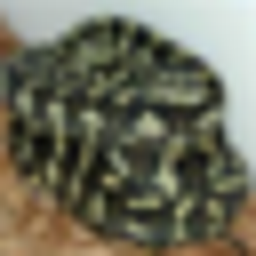

In [5]:
raw_test_set = CIFAR100(
    root=data_root,
    train=False,
    download=False
)

sample_index = 3637

raw_image, raw_label = raw_test_set[sample_index]
processed_image, processed_label = test_set[sample_index]

print("Index            :", sample_index)
print("Ground-truth ID  :", raw_label)
print("Ground-truth name:", raw_test_set.classes[raw_label])
print("Ảnh gốc          :", raw_image.size)
print("Tensor sau CLIP preprocess:", processed_image.shape)

display(raw_image.resize((256, 256)))

## 6. Tạo zero-shot classifier từ 100 class names

In [6]:
PROMPT_MODE = "official_like"

def class_to_text(name: str) -> str:
    if PROMPT_MODE == "naturalized":
        name = name.replace("_", " ")
    return f"a photo of a {name}"

prompts = [class_to_text(name) for name in test_set.classes]

print("Số prompts:", len(prompts))
print("\nMột số prompts:")
for p in prompts[:15]:
    print(" -", p)

Số prompts: 100

Một số prompts:
 - a photo of a apple
 - a photo of a aquarium_fish
 - a photo of a baby
 - a photo of a bear
 - a photo of a beaver
 - a photo of a bed
 - a photo of a bee
 - a photo of a beetle
 - a photo of a bicycle
 - a photo of a bottle
 - a photo of a bowl
 - a photo of a boy
 - a photo of a bridge
 - a photo of a bus
 - a photo of a butterfly


## 7. Tokenize và encode text

In [7]:
text_tokens = clip.tokenize(prompts).to(device)

with torch.no_grad():
    text_features = model.encode_text(text_tokens)
    text_features = text_features / text_features.norm(
        dim=-1,
        keepdim=True
    )

print("Token tensor shape :", tuple(text_tokens.shape))
print("Text feature shape :", tuple(text_features.shape))

Token tensor shape : (100, 77)
Text feature shape : (100, 512)


## 8. Kiểm tra prediction trên một ảnh

In [8]:
image, true_label = raw_test_set[sample_index]
image_input = preprocess(image).unsqueeze(0).to(device)

with torch.no_grad():
    image_features = model.encode_image(image_input)
    image_features = image_features / image_features.norm(
        dim=-1,
        keepdim=True
    )

    similarity = (
        100.0 * image_features @ text_features.T
    ).softmax(dim=-1)

values, indices = similarity[0].topk(5)

print("Ground truth:", raw_test_set.classes[true_label])
print("\nTop-5 predictions:")

for prob, idx in zip(values, indices):
    print(f"{test_set.classes[idx.item()]:>20s}: {100 * prob.item():6.2f}%")

Ground truth: snake

Top-5 predictions:
               snake:  65.31%
              turtle:  12.29%
        sweet_pepper:   3.83%
              lizard:   1.88%
           crocodile:   1.75%


## 9. Đánh giá toàn bộ CIFAR-100 test set

In [ ]:
batch_size = 256 if device == "cuda" else 64

test_loader = DataLoader(
    test_set,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=(device == "cuda")
)

correct_top1 = 0
correct_top5 = 0
total = 0

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Evaluating CIFAR-100"):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # B x D
        image_features = model.encode_image(images)

        # L2 normalization
        image_features = image_features / image_features.norm(
            dim=-1,
            keepdim=True
        )

        # (B x D) @ (D x 100) = B x 100
        logits = 100.0 * image_features @ text_features.T

        # Top-5 indices cho mỗi image
        top5 = logits.topk(k=5, dim=-1).indices

        # Top-1
        correct_top1 += (
            top5[:, 0] == labels
        ).sum().item()

        # Top-5
        correct_top5 += (
            top5 == labels[:, None]
        ).any(dim=1).sum().item()

        total += labels.size(0)

top1_acc = 100.0 * correct_top1 / total
top5_acc = 100.0 * correct_top5 / total

print(f"Model       : {model_name}")
print(f"Prompt mode : {PROMPT_MODE}")
print(f"Test images : {total}")
print(f"Top-1 Acc   : {top1_acc:.2f}%")
print(f"Top-5 Acc   : {top5_acc:.2f}%")

Evaluating CIFAR-100:   0%|          | 0/157 [00:00<?, ?it/s]

## 10. Kiểm tra shape để hiểu phép tính

Nếu batch size là \(B\):

- image features: \(B \times 512\)
- text features: \(100 \times 512\)
- similarity logits: \(B \times 100\)

Mỗi row trong similarity matrix chứa mức độ tương đồng giữa **một image** và **100 candidate class descriptions**.

In [ ]:
images, labels = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    img_feat = model.encode_image(images)
    img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
    logits = 100.0 * img_feat @ text_features.T

print("Image batch        :", tuple(images.shape))
print("Image feature      :", tuple(img_feat.shape))
print("Text feature       :", tuple(text_features.shape))
print("Similarity logits  :", tuple(logits.shape))